# Классификация: Молния vs Огненный шар

Признаки: `mana_cost`, `damage`. В таблице только 2 строки — для обучения добавляем синтетические примеры вокруг реальных заклинаний, проверку делаем на данных из PostgreSQL.

In [1]:
import os

from pyspark.sql import SparkSession

POSTGRES_JAR = os.environ.get(
    "POSTGRES_JDBC_JAR", "/opt/spark-jars/postgresql-42.7.4.jar"
)
HDFS_URL = os.environ.get("HDFS_URL", "hdfs://namenode:9000")
HDFS_PATH = f"{HDFS_URL}/data/spells"

active = SparkSession.getActiveSession()
if active is not None:
    active.stop()

spark = (
    SparkSession.builder
    .appName("jdbc-to-hdfs")
    .master("local[*]")
    .config("spark.jars", POSTGRES_JAR)
    .config("spark.hadoop.fs.defaultFS", HDFS_URL)
    .getOrCreate()
)

print("=== Чтение из PostgreSQL ===")
df = (
    spark.read.format("jdbc")
    .option("url", "jdbc:postgresql://host.docker.internal:5432/postgres")
    .option("dbtable", "spells")
    .option("user", "postgres")
    .option("password", "password")
    .option("driver", "org.postgresql.Driver")
    .load()
)

df.show()

print(f"=== Запись в HDFS: {HDFS_PATH} ===")
df.write.mode("overwrite").parquet(HDFS_PATH)

print("Готово. Чтение из HDFS — в следующей ячейке.")

26/05/22 22:14:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


=== Чтение из PostgreSQL ===
+---+------+---------------+---------+---------+------------+---------------+---------+
| id|damage|    description|image_url|mana_cost|        name|play_effect_url|sound_url|
+---+------+---------------+---------+---------+------------+---------------+---------+
|  1|     6|Наносит 6 урона|     NULL|        4|Огненный шар|           NULL|     NULL|
|  2|     6|Наносит 6 урона|     NULL|        1|      Молния|           NULL|     NULL|
+---+------+---------------+---------+---------+------------+---------------+---------+

=== Запись в HDFS: hdfs://namenode:9000/data/spells ===


Готово. Чтение из HDFS — в следующей ячейке.


## Чтение DataFrame из HDFS

In [2]:
# Нужны spark и HDFS_PATH из ячейки выше (JDBC → HDFS)
print(f"=== Чтение из HDFS: {HDFS_PATH} ===")

df_hdfs = spark.read.parquet(HDFS_PATH)

df_hdfs.show()
df_hdfs.printSchema()

print(f"Строк: {df_hdfs.count()}")

=== Чтение из HDFS: hdfs://namenode:9000/data/spells ===
+---+------+---------------+---------+---------+------------+---------------+---------+
| id|damage|    description|image_url|mana_cost|        name|play_effect_url|sound_url|
+---+------+---------------+---------+---------+------------+---------------+---------+
|  1|     6|Наносит 6 урона|     NULL|        4|Огненный шар|           NULL|     NULL|
|  2|     6|Наносит 6 урона|     NULL|        1|      Молния|           NULL|     NULL|
+---+------+---------------+---------+---------+------------+---------------+---------+

root
 |-- id: long (nullable = true)
 |-- damage: integer (nullable = true)
 |-- description: string (nullable = true)
 |-- image_url: string (nullable = true)
 |-- mana_cost: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- play_effect_url: string (nullable = true)
 |-- sound_url: string (nullable = true)

Строк: 2


In [3]:
import numpy as np

LABEL_FIREBALL = 0
LABEL_LIGHTNING = 1
CLASS_NAMES = {LABEL_FIREBALL: "Огненный шар", LABEL_LIGHTNING: "Молния"}

# Реальные строки из Spark (без pandas)
rows = df.select("mana_cost", "damage", "name").collect()

X_real, y_real, names_real = [], [], []
for row in rows:
    X_real.append([float(row.mana_cost), float(row.damage)])
    if row.name.strip() == "Молния":
        y_real.append(LABEL_LIGHTNING)
    else:
        y_real.append(LABEL_FIREBALL)
    names_real.append(row.name)

X_real = np.array(X_real)
y_real = np.array(y_real)
print("Из БД:")
for name, (mana, dmg), label in zip(names_real, X_real, y_real):
    print(f"  {name}: mana={mana:.0f}, damage={dmg:.0f} -> {CLASS_NAMES[label]}")

Из БД:
  Огненный шар: mana=4, damage=6 -> Огненный шар
  Молния: mana=1, damage=6 -> Молния


## Визуализация данных (до обучения)

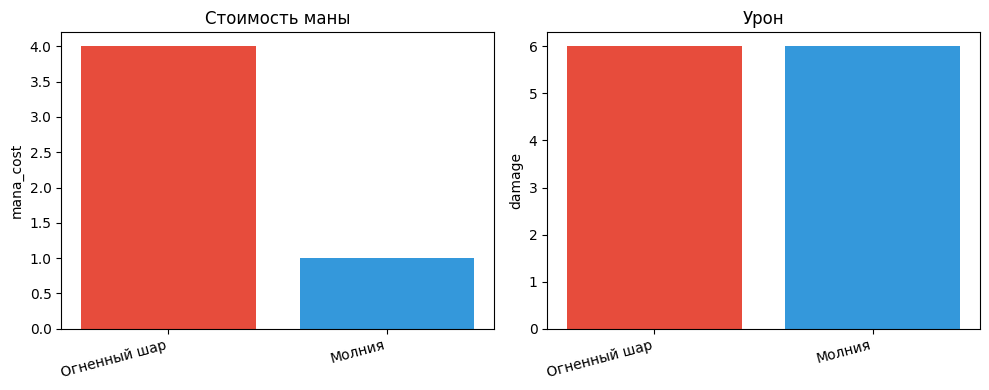

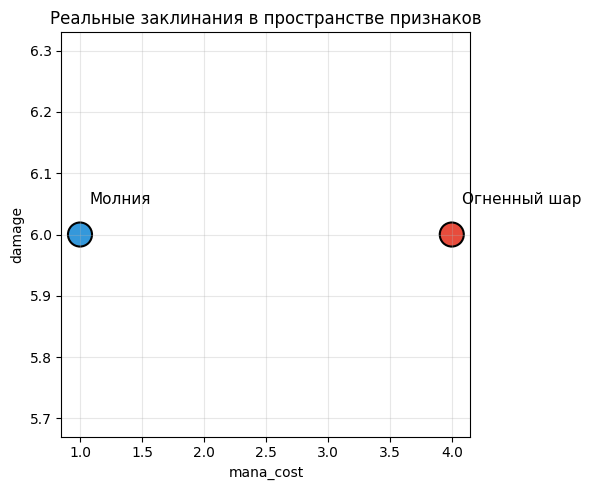

In [4]:
%matplotlib inline

import matplotlib.pyplot as plt

# --- 1. Реальные заклинания из БД: mana и damage ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

x_pos = range(len(names_real))
axes[0].bar(x_pos, X_real[:, 0], color=["#e74c3c", "#3498db"])
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels(names_real, rotation=15, ha="right")
axes[0].set_ylabel("mana_cost")
axes[0].set_title("Стоимость маны")

axes[1].bar(x_pos, X_real[:, 1], color=["#e74c3c", "#3498db"])
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(names_real, rotation=15, ha="right")
axes[1].set_ylabel("damage")
axes[1].set_title("Урон")

plt.tight_layout()
plt.show()

# --- 2. Признаковое пространство (реальные точки) ---
colors_real = ["#e74c3c" if y == LABEL_FIREBALL else "#3498db" for y in y_real]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_real[:, 0], X_real[:, 1], c=colors_real, s=300, edgecolors="black", linewidths=1.5)
for i, name in enumerate(names_real):
    ax.annotate(name, (X_real[i, 0] + 0.08, X_real[i, 1] + 0.05), fontsize=11)
ax.set_xlabel("mana_cost")
ax.set_ylabel("damage")
ax.set_title("Реальные заклинания в пространстве признаков")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
rng = np.random.default_rng(42)
N_PER_CLASS = 80

# Синтетика вокруг типичных значений классов
fireball_mana = rng.normal(4.0, 0.35, N_PER_CLASS)
fireball_damage = rng.normal(6.0, 0.4, N_PER_CLASS)

lightning_mana = rng.normal(1.0, 0.25, N_PER_CLASS)
lightning_damage = rng.normal(6.0, 0.4, N_PER_CLASS)

X_train = np.column_stack([
    np.concatenate([fireball_mana, lightning_mana]),
    np.concatenate([fireball_damage, lightning_damage]),
])
y_train = np.array(
    [LABEL_FIREBALL] * N_PER_CLASS + [LABEL_LIGHTNING] * N_PER_CLASS
)

print(f"Обучающая выборка: {len(y_train)} объектов")

Обучающая выборка: 160 объектов


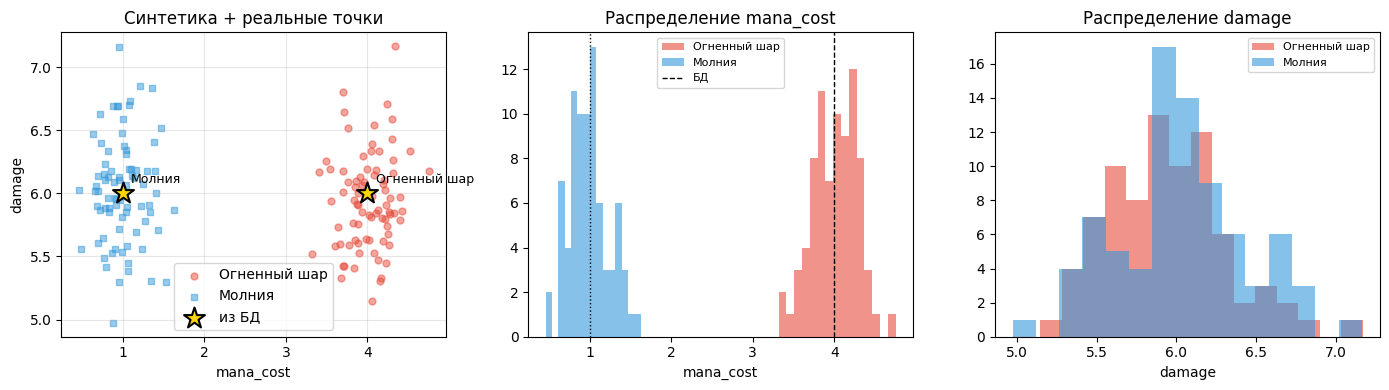

Класс 0 (Огненный шар): 80 объектов
Класс 1 (Молния): 80 объектов
Реальных для проверки: 2


In [6]:
# --- 3. Обучающая (синтетическая) выборка + реальные заклинания из БД ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for label, color, marker in [
    (LABEL_FIREBALL, "#e74c3c", "o"),
    (LABEL_LIGHTNING, "#3498db", "s"),
]:
    mask = y_train == label
    axes[0].scatter(
        X_train[mask, 0], X_train[mask, 1],
        c=color, alpha=0.5, s=25, marker=marker, label=CLASS_NAMES[label],
    )

axes[0].scatter(
    X_real[:, 0], X_real[:, 1],
    c="gold", s=250, marker="*", edgecolors="black", linewidths=1.5, label="из БД", zorder=5,
)
for i, name in enumerate(names_real):
    axes[0].annotate(name, (X_real[i, 0] + 0.1, X_real[i, 1] + 0.08), fontsize=9)
axes[0].set_xlabel("mana_cost")
axes[0].set_ylabel("damage")
axes[0].set_title("Синтетика + реальные точки")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Распределение mana_cost по классам
axes[1].hist(
    X_train[y_train == LABEL_FIREBALL, 0], bins=15, alpha=0.6, color="#e74c3c", label=CLASS_NAMES[LABEL_FIREBALL],
)
axes[1].hist(
    X_train[y_train == LABEL_LIGHTNING, 0], bins=15, alpha=0.6, color="#3498db", label=CLASS_NAMES[LABEL_LIGHTNING],
)
axes[1].axvline(X_real[0, 0], color="black", linestyle="--", linewidth=1, label="БД")
axes[1].axvline(X_real[1, 0], color="black", linestyle=":", linewidth=1)
axes[1].set_xlabel("mana_cost")
axes[1].set_title("Распределение mana_cost")
axes[1].legend(fontsize=8)

# Распределение damage по классам
axes[2].hist(
    X_train[y_train == LABEL_FIREBALL, 1], bins=15, alpha=0.6, color="#e74c3c", label=CLASS_NAMES[LABEL_FIREBALL],
)
axes[2].hist(
    X_train[y_train == LABEL_LIGHTNING, 1], bins=15, alpha=0.6, color="#3498db", label=CLASS_NAMES[LABEL_LIGHTNING],
)
axes[2].set_xlabel("damage")
axes[2].set_title("Распределение damage")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Класс 0 ({CLASS_NAMES[LABEL_FIREBALL]}): {np.sum(y_train == LABEL_FIREBALL)} объектов")
print(f"Класс 1 ({CLASS_NAMES[LABEL_LIGHTNING]}): {np.sum(y_train == LABEL_LIGHTNING)} объектов")
print(f"Реальных для проверки: {len(y_real)}")

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

CLASSIFIERS = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=50, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
}

needs_scale = {"LogisticRegression", "KNN", "SVM", "LDA"}

trained = {}
print("=== Обучение (синтетика) / проверка (реальные заклинания из БД) ===\n")

for name, clf in CLASSIFIERS.items():
    if name in needs_scale:
        model = Pipeline([
            ("scale", StandardScaler()),
            ("clf", clf),
        ])
    else:
        model = clf

    model.fit(X_train, y_train)
    pred = model.predict(X_real)
    acc = accuracy_score(y_real, pred)
    trained[name] = model

    print(f"--- {name} (accuracy на БД: {acc:.0%}) ---")
    print(classification_report(
        y_real, pred,
        target_names=[CLASS_NAMES[0], CLASS_NAMES[1]],
        zero_division=0,
    ))
    for spell_name, p in zip(names_real, pred):
        print(f"  {spell_name} -> предсказано: {CLASS_NAMES[p]}")
    print()

=== Обучение (синтетика) / проверка (реальные заклинания из БД) ===

--- LogisticRegression (accuracy на БД: 100%) ---
              precision    recall  f1-score   support

Огненный шар       1.00      1.00      1.00         1
      Молния       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

  Огненный шар -> предсказано: Огненный шар
  Молния -> предсказано: Молния

--- DecisionTree (accuracy на БД: 100%) ---
              precision    recall  f1-score   support

Огненный шар       1.00      1.00      1.00         1
      Молния       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

  Огненный шар -> предсказано: Огненный шар
  Молния -> предсказано: Молния

--- RandomForest (accuracy на

## Метрики: F1, Precision, Recall, ROC AUC

Оценка на **отложенной 25% части синтетической выборки** (честная проверка). Отдельно — на 2 реальных заклинаниях из БД.

=== Метрики на отложенной выборке (синтетика, 25%) ===
Модель                  Precision     Recall         F1    ROC AUC
------------------------------------------------------------------
LogisticRegression         1.0000     1.0000     1.0000     1.0000
DecisionTree               1.0000     1.0000     1.0000     1.0000
RandomForest               1.0000     1.0000     1.0000     1.0000
KNN                        1.0000     1.0000     1.0000     1.0000
SVM                        1.0000     1.0000     1.0000     1.0000
LDA                        1.0000     1.0000     1.0000     1.0000


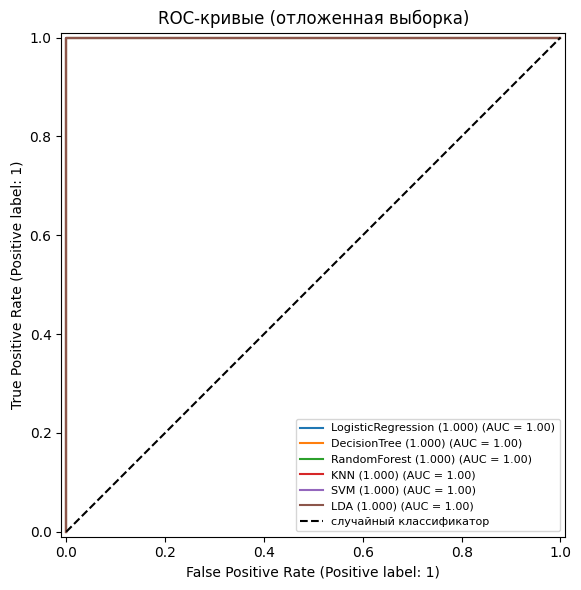


=== Метрики на реальных заклинаниях из БД (n=2) ===
Модель                  Precision     Recall         F1    ROC AUC
------------------------------------------------------------------
LogisticRegression         1.0000     1.0000     1.0000     1.0000
DecisionTree               1.0000     1.0000     1.0000     1.0000
RandomForest               1.0000     1.0000     1.0000     1.0000
KNN                        1.0000     1.0000     1.0000     1.0000
SVM                        1.0000     1.0000     1.0000     1.0000
LDA                        1.0000     1.0000     1.0000     1.0000


In [8]:
%matplotlib inline

import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split

POS_LABEL = LABEL_LIGHTNING  # положительный класс: «Молния»

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train,
)

print("=== Метрики на отложенной выборке (синтетика, 25%) ===")
print(f"{'Модель':<22} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC AUC':>10}")
print("-" * 66)

metrics_test = {}
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

for name, clf in CLASSIFIERS.items():
    if name in needs_scale:
        model = Pipeline([
            ("scale", StandardScaler()),
            ("clf", clone(clf)),
        ])
    else:
        model = clone(clf)

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    prec = precision_score(y_te, y_pred, pos_label=POS_LABEL, zero_division=0)
    rec = recall_score(y_te, y_pred, pos_label=POS_LABEL, zero_division=0)
    f1 = f1_score(y_te, y_pred, pos_label=POS_LABEL, zero_division=0)

    roc = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, POS_LABEL]
        roc = roc_auc_score(y_te, y_score)
        RocCurveDisplay.from_predictions(
            y_te, y_score, name=f"{name} ({roc:.3f})", ax=ax_roc
        )

    metrics_test[name] = {"precision": prec, "recall": rec, "f1": f1, "roc_auc": roc}
    roc_str = f"{roc:.4f}" if roc is not None else "n/a"
    print(f"{name:<22} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {roc_str:>10}")

ax_roc.plot([0, 1], [0, 1], "k--", label="случайный классификатор")
ax_roc.set_title("ROC-кривые (отложенная выборка)")
ax_roc.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print("\n=== Метрики на реальных заклинаниях из БД (n=2) ===")
print(f"{'Модель':<22} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC AUC':>10}")
print("-" * 66)

for name, model in trained.items():
    y_pred = model.predict(X_real)
    prec = precision_score(y_real, y_pred, pos_label=POS_LABEL, zero_division=0)
    rec = recall_score(y_real, y_pred, pos_label=POS_LABEL, zero_division=0)
    f1 = f1_score(y_real, y_pred, pos_label=POS_LABEL, zero_division=0)

    roc_str = "n/a"
    if hasattr(model, "predict_proba") and len(np.unique(y_real)) > 1:
        y_score = model.predict_proba(X_real)[:, POS_LABEL]
        roc_str = f"{roc_auc_score(y_real, y_score):.4f}"
    elif hasattr(model, "predict_proba"):
        roc_str = "n/a (1 класс)"

    print(f"{name:<22} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {roc_str:>10}")

In [9]:
%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


def plot_decision_boundary(model, title):
    x_min, x_max = 0.0, 5.5
    y_min, y_max = 4.5, 7.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    cmap_bg = ListedColormap(["#ffcccc", "#cce5ff"])
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)

    for label, color, marker in [
        (LABEL_FIREBALL, "red", "o"),
        (LABEL_LIGHTNING, "blue", "s"),
    ]:
        mask = y_train == label
        ax.scatter(
            X_train[mask, 0], X_train[mask, 1],
            c=color, marker=marker, alpha=0.35, s=30,
            label=f"train: {CLASS_NAMES[label]}",
        )

    for i in range(len(X_real)):
        ax.scatter(
            float(X_real[i, 0]), float(X_real[i, 1]),
            c="black", s=200, marker="*", zorder=5,
        )
        ax.annotate(
            names_real[i],
            (float(X_real[i, 0]) + 0.1, float(X_real[i, 1]) + 0.1),
            fontsize=11,
        )

    ax.set_xlabel("mana_cost")
    ax.set_ylabel("damage")
    ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


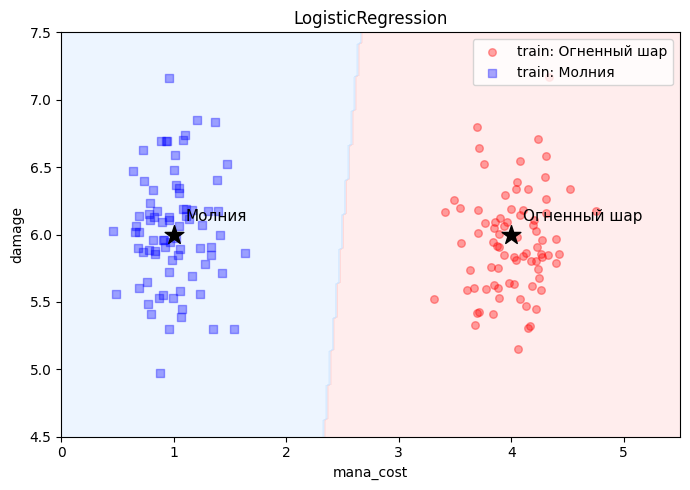

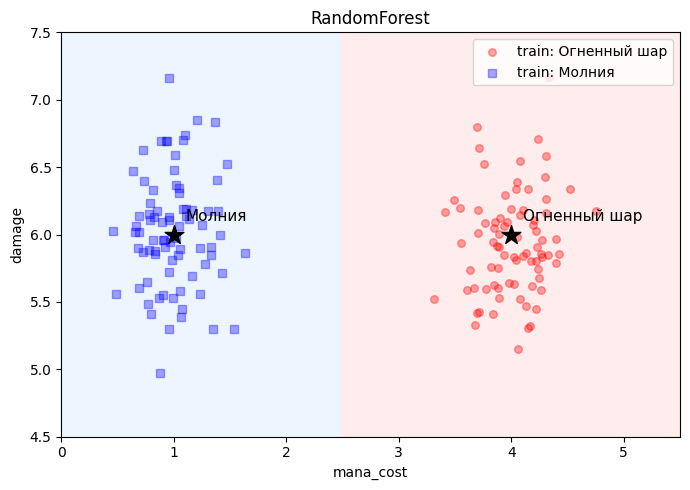

In [10]:
# Выполните после ячейки выше (с def plot_decision_boundary)
plot_decision_boundary(trained["LogisticRegression"], "LogisticRegression")
plot_decision_boundary(trained["RandomForest"], "RandomForest")


In [11]:
# Предсказание для нового заклинания
def predict_spell(mana_cost, damage, model_name="RandomForest"):
    model = trained[model_name]
    label = int(model.predict([[mana_cost, damage]])[0])
    return CLASS_NAMES[label]

print("mana=4, damage=6 ->", predict_spell(4, 6))
print("mana=1, damage=6 ->", predict_spell(1, 6))
print("mana=2, damage=5 ->", predict_spell(2, 5))

mana=4, damage=6 -> Огненный шар
mana=1, damage=6 -> Молния
mana=2, damage=5 -> Молния
